## 0 · Environment

Setup may be sticky depending on how you installed OpenMC. I use a Mac and have a python virtual environment with the related package installed

This notebook is written cross section data placed in OPENMC_PROJECT / 'XS_DATA', you may have to change this yourself.

Later sections require an OpenMC executable which we will call within

Good luck!

In [10]:
from pathlib import Path
import os
import sys
import time

# Edit this one path, or set OPENMC_PROJECT in your environment.
# Expected layout: openmc/, XS_DATA/, and work/ below the project root.
OPENMC_PROJECT = Path('/Users/user/Documents/OPENMC') # This is how it is for my Mac!
OPENMC_ROOT = OPENMC_PROJECT / 'openmc'
PYTHON_ENV = OPENMC_ROOT / 'openMC_py'
OPENMC_EXEC = OPENMC_ROOT / 'build/bin/openmc'
OPENMC_CROSS_SECTIONS = OPENMC_PROJECT / 'XS_DATA/endfb-viii.0-hdf5/cross_sections.xml'
WORK = OPENMC_PROJECT / 'work/openmc_v7_runs'  # reuse existing calculation files
REUSE_CALCULATIONS = True  # set False after changing model or run inputs
FIGURES = Path.cwd() / 'figures_v9'
FIGURES.mkdir(parents=True, exist_ok=True)
THREADS = 4

if Path(sys.executable).resolve() != (PYTHON_ENV / 'bin/python').resolve():
    raise RuntimeError(f'Select the Jupyter kernel from {PYTHON_ENV}; current: {sys.executable}')
if not OPENMC_CROSS_SECTIONS.is_file():
    raise FileNotFoundError(OPENMC_CROSS_SECTIONS)
WORK.mkdir(parents=True, exist_ok=True)
MPL_CACHE = Path.cwd() / '.matplotlib_cache'
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPL_CACHE)
os.environ['OPENMC_CROSS_SECTIONS'] = str(OPENMC_CROSS_SECTIONS)

import numpy as np
import matplotlib.pyplot as plt
import openmc

openmc.config['cross_sections'] = str(OPENMC_CROSS_SECTIONS)
library = openmc.data.DataLibrary.from_xml(str(OPENMC_CROSS_SECTIONS))
print('OpenMC:', openmc.__version__)
print('Cross sections:', OPENMC_CROSS_SECTIONS)
# One readable visual system for the Substack figures.
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'axes.labelweight': 'bold',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'savefig.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#D9DEE6', 'grid.linewidth': 0.7,
})


OpenMC: 0.15.4.dev139+g8223099ed
Cross sections: /Users/user/Documents/OPENMC/XS_DATA/endfb-viii.0-hdf5/cross_sections.xml


## 1 · Evaluated-data plots

Cross section and other nuclear data plots!

The prompt fission spectra use the tabulated incident energy nearest **2 MeV** for the three plotted isotopes. Cross sections use eV and barns; MT=18 is fission and MT=102 is neutron capture.


In [11]:
PLOT_ISOTOPES = ('Th232', 'U233', 'Pu239')
ALL_ISOTOPES = ('Th232', 'U233', 'U235', 'U238', 'Pu239', 'Pu241')
COLORS = {'Th232': '#0072B2', 'U233': '#E69F00', 'Pu239': '#7B3294'}
FAST_ENERGY_EV = 2.0e6

def load_neutron_data(name):
    path = library.get_by_material(name, data_type='neutron')['path']
    return openmc.data.IncidentNeutron.from_hdf5(path)

data = {name: load_neutron_data(name) for name in ALL_ISOTOPES}

def xs(name, mt, energy_eV):
    return np.asarray(data[name].reactions[mt].xs['294K'](energy_eV), dtype=float)

def nubar(name, energy_eV):
    return sum(p.yield_(energy_eV) for p in data[name].reactions[18].products
               if p.particle == 'neutron')

def fission_fraction(name, energy_eV):
    sigma_f = xs(name, 18, energy_eV)
    sigma_cap = xs(name, 102, energy_eV)
    denominator = sigma_f + sigma_cap
    return np.divide(sigma_f, denominator,
                     out=np.zeros_like(denominator, dtype=float),
                     where=denominator > 0)

def prompt_spectrum(name, incident_eV=FAST_ENERGY_EV):
    prompt = next(p for p in data[name].reactions[18].products
                  if p.particle == 'neutron' and p.emission_mode == 'prompt')
    distribution = prompt.distribution[0]
    if hasattr(distribution.energy, 'energy'):
        incident_grid = np.asarray(distribution.energy.energy)
        outgoing = distribution.energy.energy_out
    elif hasattr(distribution, "energy_out"):  # correlated angle-energy representation
        incident_grid = np.asarray(distribution.energy)
        outgoing = distribution.energy_out
    else:  # analytic Maxwellian prompt spectrum (Pu-241 in this library)
        theta = float(distribution.energy.theta(incident_eV))
        upper = incident_eV - distribution.energy.u
        energy = np.linspace(0.0, upper, 2001)
        density = np.sqrt(energy) * np.exp(-energy / theta)
        density /= np.trapezoid(density, energy)
        return float(incident_eV), energy, density
    index = int(np.argmin(np.abs(incident_grid - incident_eV)))
    curve = outgoing[index]
    energy = np.asarray(curve.x, dtype=float)
    density = np.asarray(curve.p, dtype=float)
    density /= np.trapezoid(density, energy)
    return float(incident_grid[index]), energy, density

spectra = {name: prompt_spectrum(name) for name in ALL_ISOTOPES}
for name in PLOT_ISOTOPES:
    incident, _, _ = spectra[name]
    print(f'{name}: nearest tabulated incident energy = {incident/1e6:.3f} MeV')

Th232: nearest tabulated incident energy = 2.000 MeV
U233: nearest tabulated incident energy = 2.000 MeV
Pu239: nearest tabulated incident energy = 2.000 MeV


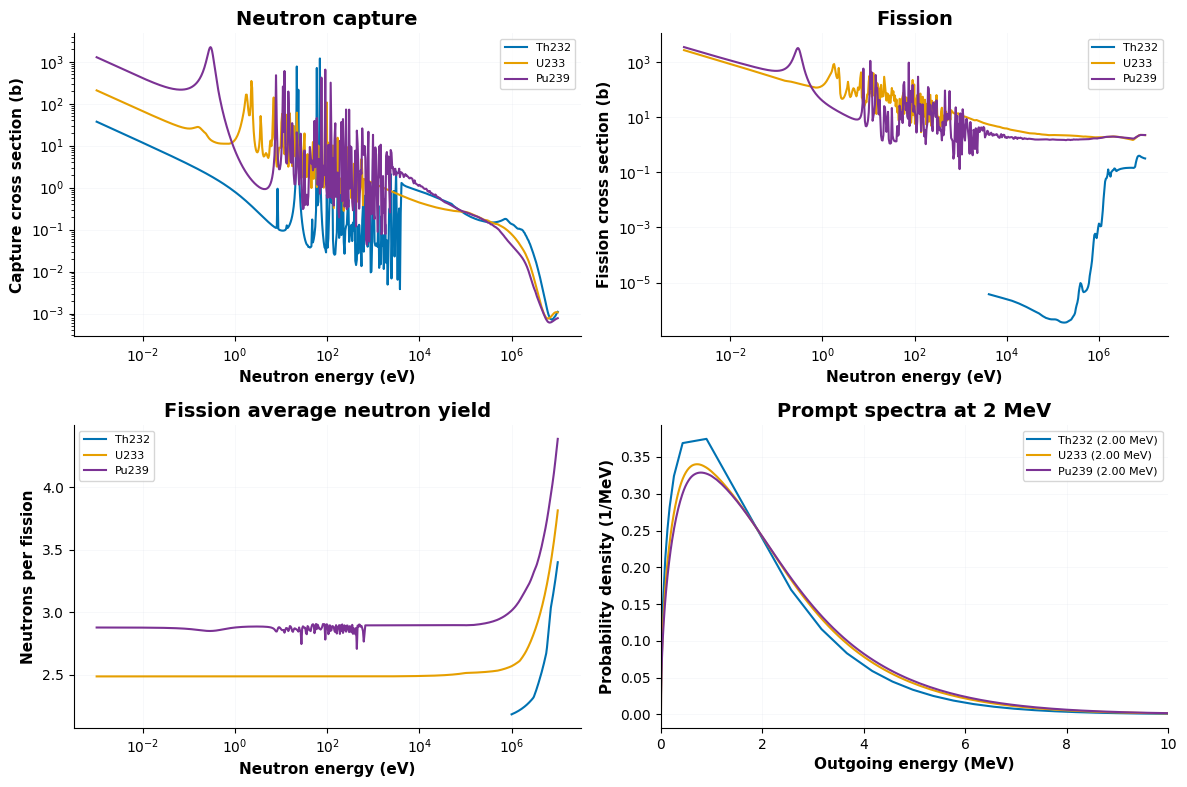

In [12]:
energy_grid = np.logspace(-3, 7, 600)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for name in PLOT_ISOTOPES:
    color = COLORS[name]
    fission_curve = xs(name, 18, energy_grid)
    axes[0, 0].loglog(energy_grid, xs(name, 102, energy_grid), color=color,
                      label=name)
    axes[0, 1].loglog(energy_grid, np.where(fission_curve > 0, fission_curve, np.nan),
                      color=color, label=name)
    nu = np.asarray(nubar(name, energy_grid), dtype=float)
    axes[1, 0].semilogx(energy_grid, np.where(fission_curve > 1e-3, nu, np.nan),
                         color=color, label=name)
    incident, outgoing, density = spectra[name]
    axes[1, 1].plot(outgoing / 1e6, density * 1e6, color=color,
                    label=f'{name} ({incident/1e6:.2f} MeV)')

axes[0, 0].set(xlabel='Neutron energy (eV)', ylabel='Capture cross section (b)',
               title='Neutron capture')
axes[0, 1].set(xlabel='Neutron energy (eV)', ylabel='Fission cross section (b)',
               title='Fission')
axes[1, 0].set(xlabel='Neutron energy (eV)', ylabel='Neutrons per fission',
               title='Fission average neutron yield')
axes[1, 1].set(xlim=(0, 10), xlabel='Outgoing energy (MeV)',
               ylabel='Probability density (1/MeV)', title='Prompt spectra at 2 MeV')
for ax in axes.flat:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 2 · Fast-energy isotope calculations and spectrum weighting

Every value in the table is an integral over the outgoing-energy grid of that isotope's fission neutron spectrum: $\langle\sigma_\gamma\rangle_\chi$, $\langle\sigma_f\rangle_\chi$, $\langle\bar\nu\rangle_\chi$, $\langle P_f\rangle_\chi$, and $\langle\eta^*\rangle_\chi$. 

Here $P_f(E)=\sigma_f(E)/(\sigma_f(E)+\sigma_\gamma(E))$ and $\eta^*(E)=\bar\nu(E)P_f(E)$. In particular, $\langle\eta^*\rangle_\chi$ integrates the product at each energy; it is not the product of the separately averaged columns.


In [13]:
print(f"{'isotope':<8} {'chi norm':>9} {'capture b':>11} {'fission b':>11} {'nu-bar':>9} {'P_f':>9} {'eta*':>9}")
for name in ALL_ISOTOPES:
    incident, outgoing, density = spectra[name]
    chi_norm = float(np.trapezoid(density, outgoing))
    if not np.isclose(chi_norm, 1.0, atol=1e-6):
        raise ValueError(f'{name} prompt spectrum is not normalized: {chi_norm}')
    capture_curve = xs(name, 102, outgoing)
    fission_curve = xs(name, 18, outgoing)
    nu_curve = np.asarray(nubar(name, outgoing), dtype=float)
    p_f_curve = fission_fraction(name, outgoing)
    if not np.all(np.isfinite(nu_curve)):
        raise ValueError(f'{name} neutron yield is non-finite on its spectrum grid')
    weighted = lambda values: float(np.trapezoid(density * values, outgoing))
    capture = weighted(capture_curve)
    fission = weighted(fission_curve)
    nu = weighted(nu_curve)
    p_fission = weighted(p_f_curve)
    eta_star = weighted(nu_curve * p_f_curve)
    print(f'{name:<8} {chi_norm:9.4f} {capture:11.4g} {fission:11.4g} '
          f'{nu:9.3f} {p_fission:9.4f} {eta_star:9.3f}')


isotope   chi norm   capture b   fission b    nu-bar       P_f      eta*
Th232       1.0000      0.1053      0.0554     2.254    0.3314     0.801
U233        1.0000      0.0575       1.906     2.714    0.9728     2.644
U235        1.0000     0.09168       1.226     2.666    0.9352     2.501
U238        1.0000     0.07032      0.3049     2.644    0.5773     1.582
Pu239       1.0000     0.04155       1.802     3.191    0.9769     3.122
Pu241       1.0000     0.09157       1.598     3.204    0.9487     3.046


## 3 · Start of life CANDU-like bundle test

Edit `PIN_LOADING` in the next cell to choose every pin's fuel. Ring 0 is the centre. For rings 1–3, tuple item 0 is at the ring's listed start angle; subsequent items proceed anticlockwise. Use `'U'` or `'Th'` for each of the 1 + 6 + 12 + 18 positions. Play around yourself!

The default configured case puts uranium in the centre and thorium in the first ring (6 pins). The all-uranium control ignores that map but keeps the same geometry. The geometry follows the [OpenMC CANDU bundle example](https://docs.openmc.org/en/v0.9.0/examples/candu.html).

`make_static_model` continues to supply both the static comparisons and the depletion model. Fuel is lumped by type for depletion, with volumes calculated from the configured pin counts.


37-pin loading: 6 thorium, 31 uranium


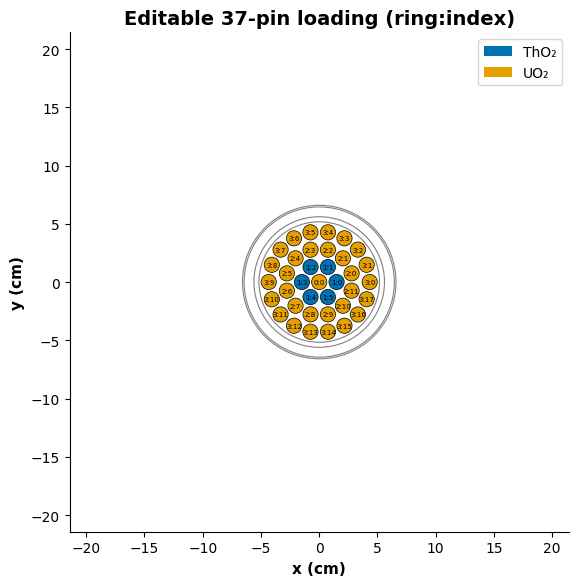

In [14]:
# Editable CANDU-like bundle inputs (cm, K, g/cm3 unless noted)
RING_RADII_CM = (0.0, 1.4885, 2.8755, 4.3305)
RING_START_ANGLES_DEG = (0.0, 0.0, 15.0, 0.0)
# Each tuple is ordered counterclockwise from its start angle; edit any entry.
PIN_LOADING = (
    ('U',),
    ('Th',) * 6,
    ('U',) * 12,
    ('U',) * 18,
)
FUEL_RADIUS_CM = 0.6122
CLAD_INNER_RADIUS_CM = 0.6200
CLAD_OUTER_RADIUS_CM = 0.6540
PRESSURE_TUBE_INNER_CM = 5.16890
PRESSURE_TUBE_OUTER_CM = 5.60320
CALANDRIA_TUBE_INNER_CM = 6.44780
CALANDRIA_TUBE_OUTER_CM = 6.58750
CHANNEL_PITCH_CM = 1.5 * 28.575
ACTIVE_HEIGHT_CM = 49.5333
U235_ENRICHMENT_WT_PCT = 0.711
UO2_DENSITY = 10.40
THO2_DENSITY = 9.50
HE_GAP_DENSITY = 0.001
ZIRCALOY_DENSITY = 6.55
COOLANT_D2O_DENSITY = 0.90
MODERATOR_D2O_DENSITY = 1.10
FUEL_TEMPERATURE_K = 600.0
GAP_TEMPERATURE_K = 520.0
CLAD_TEMPERATURE_K = 500.0
COOLANT_TEMPERATURE_K = 440.0
MODERATOR_TEMPERATURE_K = 300.0
STATIC_PARTICLES = 10000
STATIC_INACTIVE = 50
STATIC_BATCHES = 500
FLUX_MESH_BINS = 100
PROGRESS_EVERY_BATCHES = 25
PROGRESS_INTERVAL_S = 30

from math import cos, sin, pi
import re
import subprocess
import threading
from matplotlib.patches import Circle, Patch

assert tuple(map(len, PIN_LOADING)) == (1, 6, 12, 18)
assert all(fuel in ('U', 'Th') for ring in PIN_LOADING for fuel in ring)
assert 0 < FUEL_RADIUS_CM < CLAD_INNER_RADIUS_CM < CLAD_OUTER_RADIUS_CM
assert RING_RADII_CM[-1] + CLAD_OUTER_RADIUS_CM < PRESSURE_TUBE_INNER_CM
assert PRESSURE_TUBE_INNER_CM < PRESSURE_TUBE_OUTER_CM < CALANDRIA_TUBE_INNER_CM < CALANDRIA_TUBE_OUTER_CM < CHANNEL_PITCH_CM/2
assert ACTIVE_HEIGHT_CM > 0 and STATIC_BATCHES > STATIC_INACTIVE >= 0
assert FLUX_MESH_BINS > 0 and PROGRESS_EVERY_BATCHES > 0 and PROGRESS_INTERVAL_S > 0

PIN_POSITIONS = tuple(
    (ring, index,
     radius * cos(np.deg2rad(RING_START_ANGLES_DEG[ring] + index*360/len(PIN_LOADING[ring]))),
     radius * sin(np.deg2rad(RING_START_ANGLES_DEG[ring] + index*360/len(PIN_LOADING[ring]))))
    for ring, radius in enumerate(RING_RADII_CM)
    for index in range(len(PIN_LOADING[ring]))
)
assert all(np.hypot(x1-x2, y1-y2) > 2*CLAD_OUTER_RADIUS_CM
           for k, (_, _, x1, y1) in enumerate(PIN_POSITIONS)
           for _, _, x2, y2 in PIN_POSITIONS[k+1:])
print(f'37-pin loading: {sum(f == "Th" for ring in PIN_LOADING for f in ring)} thorium, '
      f'{sum(f == "U" for ring in PIN_LOADING for f in ring)} uranium')

def make_static_model(with_thorium=True, flux_tally=False, depletable_fuel=False,
                      uranium_material=None, thorium_material=None):
    """Build the CANDU-like channel model shared by Sections 3 and 4."""
    selected = PIN_LOADING if with_thorium else tuple(('U',)*len(ring) for ring in PIN_LOADING)
    n_th_pins = sum(f == 'Th' for ring in selected for f in ring)
    n_u_pins = 37 - n_th_pins
    if depletable_fuel and not (n_th_pins and n_u_pins):
        raise ValueError('Depletion needs at least one U pin and one Th pin')

    if uranium_material is None:
        uranium = openmc.Material(name='natural uranium dioxide')
        uranium.set_density('g/cm3', UO2_DENSITY)
        uranium.add_element('U', 1, enrichment=U235_ENRICHMENT_WT_PCT)
        uranium.add_element('O', 2)
        uranium.temperature = FUEL_TEMPERATURE_K
    else:
        uranium = uranium_material

    if thorium_material is None:
        thorium = openmc.Material(name='thorium dioxide')
        thorium.set_density('g/cm3', THO2_DENSITY)
        thorium.add_nuclide('Th232', 1)
        thorium.add_element('O', 2)
        thorium.temperature = FUEL_TEMPERATURE_K
    else:
        thorium = thorium_material

    if depletable_fuel:
        pellet_volume = pi * FUEL_RADIUS_CM**2 * ACTIVE_HEIGHT_CM
        uranium.volume = n_u_pins * pellet_volume
        thorium.volume = n_th_pins * pellet_volume
        uranium.depletable = True
        thorium.depletable = True

    gap = openmc.Material(name='helium gap')
    gap.set_density('g/cm3', HE_GAP_DENSITY)
    gap.add_element('He', 1)
    gap.temperature = GAP_TEMPERATURE_K
    clad = openmc.Material(name='zirconium cladding and tubes')
    clad.set_density('g/cm3', ZIRCALOY_DENSITY)
    clad.add_element('Zr', 1)
    clad.temperature = CLAD_TEMPERATURE_K
    def heavy_water(name, density, temperature):
        material = openmc.Material(name=name)
        material.add_nuclide('H2', 2)
        material.add_nuclide('O16', 1)
        material.add_s_alpha_beta('c_D_in_D2O')
        material.set_density('g/cm3', density)
        material.temperature = temperature
        return material
    coolant = heavy_water('heavy-water coolant', COOLANT_D2O_DENSITY, COOLANT_TEMPERATURE_K)
    moderator = heavy_water('heavy-water moderator', MODERATOR_D2O_DENSITY, MODERATOR_TEMPERATURE_K)

    pellet_edge = openmc.ZCylinder(r=FUEL_RADIUS_CM)
    gap_edge = openmc.ZCylinder(r=CLAD_INNER_RADIUS_CM)
    clad_edge = openmc.ZCylinder(r=CLAD_OUTER_RADIUS_CM)
    def pin(fuel):
        return openmc.Universe(cells=[
            openmc.Cell(fill=fuel, region=-pellet_edge),
            openmc.Cell(fill=gap, region=+pellet_edge & -gap_edge),
            openmc.Cell(fill=clad, region=+gap_edge & -clad_edge),
        ])
    pin_universes = {'U': pin(uranium), 'Th': pin(thorium)}

    pt_inner = openmc.ZCylinder(r=PRESSURE_TUBE_INNER_CM)
    pt_outer = openmc.ZCylinder(r=PRESSURE_TUBE_OUTER_CM)
    cal_inner = openmc.ZCylinder(r=CALANDRIA_TUBE_INNER_CM)
    cal_outer = openmc.ZCylinder(r=CALANDRIA_TUBE_OUTER_CM)
    coolant_region = -pt_inner
    bundle_cells = []
    for ring, index, x, y in PIN_POSITIONS:
        pin_boundary = openmc.ZCylinder(x0=x, y0=y, r=CLAD_OUTER_RADIUS_CM)
        coolant_region &= +pin_boundary
        cell = openmc.Cell(fill=pin_universes[selected[ring][index]], region=-pin_boundary)
        cell.translation = (x, y, 0)
        bundle_cells.append(cell)
    bundle_cells.append(openmc.Cell(fill=coolant, region=coolant_region))
    bundle_universe = openmc.Universe(cells=bundle_cells)

    half_pitch = CHANNEL_PITCH_CM/2
    x0 = openmc.XPlane(x0=-half_pitch, boundary_type='reflective')
    x1 = openmc.XPlane(x0=half_pitch, boundary_type='reflective')
    y0 = openmc.YPlane(y0=-half_pitch, boundary_type='reflective')
    y1 = openmc.YPlane(y0=half_pitch, boundary_type='reflective')
    z0 = openmc.ZPlane(z0=-ACTIVE_HEIGHT_CM/2, boundary_type='reflective')
    z1 = openmc.ZPlane(z0=ACTIVE_HEIGHT_CM/2, boundary_type='reflective')
    outer_region = +x0 & -x1 & +y0 & -y1 & +z0 & -z1
    root = openmc.Universe(cells=[
        openmc.Cell(fill=bundle_universe, region=-pt_inner & outer_region),
        openmc.Cell(fill=clad, region=+pt_inner & -pt_outer & outer_region),
        openmc.Cell(fill=gap, region=+pt_outer & -cal_inner & outer_region),
        openmc.Cell(fill=clad, region=+cal_inner & -cal_outer & outer_region),
        openmc.Cell(fill=moderator, region=+cal_outer & outer_region),
    ])

    settings = openmc.Settings()
    settings.run_mode = 'eigenvalue'
    settings.particles = STATIC_PARTICLES
    settings.inactive = STATIC_INACTIVE
    settings.batches = STATIC_BATCHES
    settings.temperature = {'method': 'interpolation'}
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Box((-PRESSURE_TUBE_INNER_CM, -PRESSURE_TUBE_INNER_CM, -ACTIVE_HEIGHT_CM/2),
                               ( PRESSURE_TUBE_INNER_CM,  PRESSURE_TUBE_INNER_CM,  ACTIVE_HEIGHT_CM/2)),
        constraints={'fissionable': True})
    model = openmc.Model(
        geometry=openmc.Geometry(root),
        materials=openmc.Materials([uranium, thorium, gap, clad, coolant, moderator]),
        settings=settings)
    if flux_tally:
        mesh = openmc.RegularMesh()
        mesh.dimension = (FLUX_MESH_BINS, FLUX_MESH_BINS, 1)
        mesh.lower_left = (-half_pitch, -half_pitch, -ACTIVE_HEIGHT_CM/2)
        mesh.upper_right = (half_pitch, half_pitch, ACTIVE_HEIGHT_CM/2)
        tally = openmc.Tally(name='pin_pitch_flux_map')
        tally.filters = [openmc.MeshFilter(mesh)]
        tally.scores = ['flux']
        model.tallies = openmc.Tallies([tally])
    return model

half_pitch = CHANNEL_PITCH_CM/2
fig, ax = plt.subplots(figsize=(6, 6))
for ring, index, x, y in PIN_POSITIONS:
    color = COLORS['Th232'] if PIN_LOADING[ring][index] == 'Th' else COLORS['U233']
    ax.add_patch(Circle((x, y), CLAD_OUTER_RADIUS_CM, facecolor=color, edgecolor='black', lw=0.5))
    ax.text(x, y, f'{ring}:{index}', ha='center', va='center', fontsize=5, color='black')
for radius in (PRESSURE_TUBE_INNER_CM, PRESSURE_TUBE_OUTER_CM,
               CALANDRIA_TUBE_INNER_CM, CALANDRIA_TUBE_OUTER_CM):
    ax.add_patch(Circle((0, 0), radius, fill=False, edgecolor='gray', lw=0.8))
ax.set(xlim=(-half_pitch, half_pitch), ylim=(-half_pitch, half_pitch), aspect='equal',
       xlabel='x (cm)', ylabel='y (cm)', title='Editable 37-pin loading (ring:index)')
ax.legend(handles=[Patch(facecolor=COLORS['Th232'], label='ThO₂'),
                   Patch(facecolor=COLORS['U233'], label='UO₂')], loc='upper right')
fig.tight_layout()
plt.show()


### Start of life runs and flux maps

Our first OpenMC run, runs both back to back, tells you keff and prints off the flux map for our customised case.

Set `RUN_ALL_URANIUM_STATIC = False` at the top of the next cell to run only the configured loading

all_uranium_static: using saved /Users/user/Documents/OPENMC/work/openmc_v7_runs/all_uranium_static/statepoint.500.h5
configured_mixed_static: using saved /Users/user/Documents/OPENMC/work/openmc_v7_runs/configured_mixed_static/statepoint.500.h5
All uranium: k = 1.17510 ± 0.00040; saved run
Configured mixed: k = 1.03918 ± 0.00037; saved run


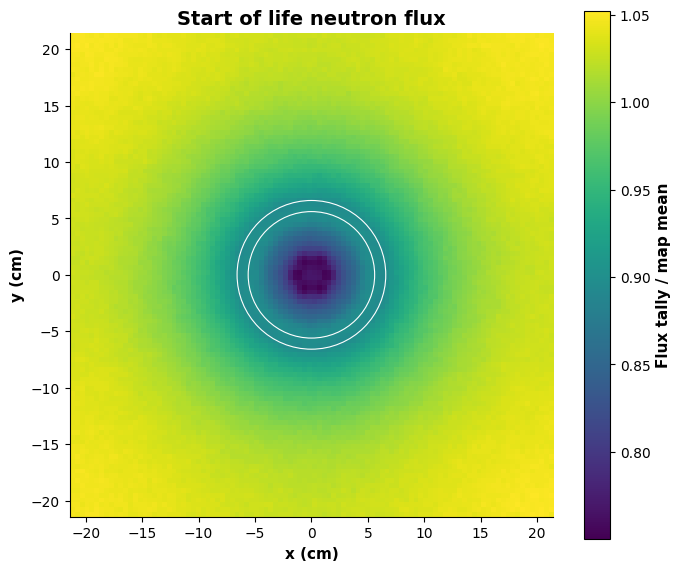

In [15]:
# Static-run flag: the configured loading always runs.
RUN_ALL_URANIUM_STATIC = True  # False skips the all-uranium control

if not OPENMC_EXEC.is_file():
    raise FileNotFoundError(OPENMC_EXEC)

def run_model_with_progress(model, folder, label):
    """Run OpenMC and report an ETA from completed batches."""
    folder.mkdir(parents=True, exist_ok=True)
    model.export_to_model_xml(path=folder / 'model.xml')
    command = [str(OPENMC_EXEC), '-s', str(THREADS), 'model.xml']
    started = time.perf_counter()
    print(f'{label}: starting {model.settings.batches} batches × '
          f'{model.settings.particles:,} particles', flush=True)
    process = subprocess.Popen(command, cwd=folder, stdout=subprocess.PIPE,
                               stderr=subprocess.STDOUT, text=True, bufsize=1)
    last_lines = []
    first_batch_time = None
    progress = {'batch': 0, 'per_batch': None}
    done = threading.Event()
    def heartbeat():
        while not done.wait(PROGRESS_INTERVAL_S):
            elapsed = time.perf_counter() - started
            if progress['per_batch'] is None:
                estimate = 'ETA after two batches'
            else:
                remaining = progress['per_batch'] * (model.settings.batches - progress['batch'])
                estimate = f'~{remaining/60:.1f} min left'
            print(f'{label}: batch {progress["batch"]}/{model.settings.batches}; '
                  f'{elapsed/60:.1f} min elapsed; {estimate}', flush=True)
    reporter = threading.Thread(target=heartbeat, daemon=True)
    reporter.start()
    try:
        for line in process.stdout:
            last_lines.append(line)
            last_lines = last_lines[-25:]
            match = re.search(r'^\s*(\d+)/\d+\s+[-+\d.]', line)
            if match:
                batch = int(match.group(1))
                if batch == 1:
                    first_batch_time = time.perf_counter()
                progress['batch'] = batch
                if batch > 1 and first_batch_time is not None:
                    progress['per_batch'] = (time.perf_counter() - first_batch_time) / (batch - 1)
                if batch == 1 or batch % PROGRESS_EVERY_BATCHES == 0 or batch == model.settings.batches:
                    elapsed = time.perf_counter() - started
                    if progress['per_batch'] is not None:
                        remaining = progress['per_batch'] * (model.settings.batches - batch)
                        estimate = f'~{remaining/60:.1f} min left'
                    else:
                        estimate = 'ETA after next batch'
                    print(f'{label}: batch {batch}/{model.settings.batches}; '
                          f'{elapsed/60:.1f} min elapsed; {estimate}', flush=True)
            elif 'ERROR:' in line:
                print(line.rstrip(), flush=True)
    finally:
        done.set()
        reporter.join()
        process.stdout.close()
    if process.wait() != 0:
        raise RuntimeError(f'{label} OpenMC failed:\n' + ''.join(last_lines))
    statepoint_path = folder / f'statepoint.{model.settings.batches}.h5'
    if not statepoint_path.is_file():
        raise FileNotFoundError(statepoint_path)
    return statepoint_path, time.perf_counter() - started

def run_static_case(tag, with_thorium, flux_tally):
    model = make_static_model(with_thorium=with_thorium, flux_tally=flux_tally)
    statepoint_path = WORK / tag / f'statepoint.{model.settings.batches}.h5'
    if REUSE_CALCULATIONS and statepoint_path.is_file():
        elapsed = np.nan
        print(f'{tag}: using saved {statepoint_path}')
    else:
        statepoint_path, elapsed = run_model_with_progress(model, WORK / tag, tag)
    with openmc.StatePoint(statepoint_path) as statepoint:
        result = {'keff': statepoint.keff, 'elapsed_s': elapsed}
        if flux_tally:
            tally = statepoint.get_tally(name='pin_pitch_flux_map')
            result['flux_map'] = tally.mean.reshape((FLUX_MESH_BINS, FLUX_MESH_BINS))
    return result

control = None
static_results = []
if RUN_ALL_URANIUM_STATIC:
    control = run_static_case('all_uranium_static', False, False)
    static_results.append(('All uranium', control))
mixed = run_static_case('configured_mixed_static', True, True)
static_results.append(('Configured mixed', mixed))
for label, result in static_results:
    print(f"{label}: k = {result['keff'].nominal_value:.5f} ± "
          f"{result['keff'].std_dev:.5f}" +
          (f"; {result['elapsed_s']:.1f} s" if np.isfinite(result['elapsed_s']) else '; saved run'))
histories = STATIC_PARTICLES * STATIC_BATCHES
if np.isfinite(mixed['elapsed_s']):
    print(f"Mixed-case throughput: {histories/mixed['elapsed_s']:,.0f} histories/s "
          '(includes setup and inactive batches)')

flux = mixed['flux_map']
normalized_flux = flux / np.nanmean(flux)
half_pitch = CHANNEL_PITCH_CM/2
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(normalized_flux, origin='lower', cmap='viridis',
               extent=(-half_pitch, half_pitch, -half_pitch, half_pitch))
for radius in (PRESSURE_TUBE_OUTER_CM, CALANDRIA_TUBE_OUTER_CM):
    ax.add_patch(Circle((0, 0), radius, fill=False, edgecolor='white', lw=0.8))
ax.set(xlabel='x (cm)', ylabel='y (cm)', title='Start of life neutron flux')
fig.colorbar(im, ax=ax, label='Flux tally / map mean')
fig.tight_layout()
plt.show()


## 4 · Depletion (burnup) of the configured mixed bundle

This section depletes the Section 3 loading with `make_static_model(..., depletable_fuel=True)`. Uranium and thorium pins each share a single averaged fuel composition for simplicity; their lumped volumes are pellet area × active height × the configured number of pins of that type. 

The calculation tracks Th-232 → Pa-233 → U-233 and U-238 → U-239 → Np-239 → Pu-239 alongside U-235 burnup. The illustrative bundle power is scaled from a vaguely realistic power per pin. Progress messages print during each transport solve and after each depletion step.

Flux maps are plotted at 3 of the burnup steps, followed by inventory plots.

The inventory plots additionally include thorium/protactinium intermediates, U-232/U-234/U-236, and higher plutonium isotopes. These selections control post-processing; the full configured depletion chain continues to determine which nuclides evolve. Major and bred/transient inventories use separate plots. The following atom-ratio plot uses U-238/Pu-239 in uranium fuel and Th-232/U-233 in thorium fuel. The final plot shows **10⁶ × N(U-232)/N(U-233)** in thorium fuel (atom ppm).


In [16]:
# Editable depletion-run inputs
OPENMC_CHAIN_FILE = OPENMC_PROJECT / 'XS_DATA/chain_endfb80_pwr.xml'

# Per-burnup-step transport settings (these apply only to the depletion model
# below; the Section 3 static case keeps using STATIC_PARTICLES/INACTIVE/BATCHES)
DEPLETION_PARTICLES = 5000
DEPLETION_INACTIVE = 5
DEPLETION_BATCHES = 100

# Power and burnup schedule
DEPLETION_POWER_W = 3.3e5                 # whole 37-pin bundle, W; scaled from v5 per-pin power
DEPLETION_STEP_DAYS = [30.0] * 6          # six 30-day steps = 180 days total
DEPLETION_INTEGRATOR = 'predictor'        # 'predictor' (fast, 1st-order) or 'cecm' (slower, 2nd-order)

# Burnup steps (0 = beginning-of-life) at which the flux map is re-solved;
# must be sorted and within range(len(DEPLETION_STEP_DAYS) + 1)
DEPLETION_FLUX_STAGE_STEPS = (0, len(DEPLETION_STEP_DAYS)//2, len(DEPLETION_STEP_DAYS))

# Isotopes tracked in Section 4's plots; must exist in the chain file
DEPLETION_THORIUM_ISOTOPES = ('Th232', 'Th233', 'Pa231', 'Pa232', 'Pa233', 'U232', 'U233', 'U234')
DEPLETION_URANIUM_ISOTOPES = ('U235', 'U236', 'U238', 'U239', 'Np239', 'Pu239', 'Pu240', 'Pu241', 'Pu242')

if not OPENMC_CHAIN_FILE.is_file():
    raise FileNotFoundError(OPENMC_CHAIN_FILE)
assert DEPLETION_BATCHES > DEPLETION_INACTIVE >= 0
assert all(step > 0 for step in DEPLETION_STEP_DAYS)
assert DEPLETION_FLUX_STAGE_STEPS == tuple(sorted(DEPLETION_FLUX_STAGE_STEPS))
assert DEPLETION_FLUX_STAGE_STEPS[-1] <= len(DEPLETION_STEP_DAYS)
assert DEPLETION_INTEGRATOR in ('predictor', 'cecm')

import openmc.deplete

# Fail before transport if a selected inventory nuclide is absent from the chain.
chain = openmc.deplete.Chain.from_xml(str(OPENMC_CHAIN_FILE))
missing_isotopes = (set(DEPLETION_THORIUM_ISOTOPES + DEPLETION_URANIUM_ISOTOPES)
                    - set(chain.nuclide_dict))
if missing_isotopes:
    raise ValueError(f'Depletion chain is missing selected nuclides: {sorted(missing_isotopes)}')
import openmc.deplete.pool as depletion_pool
depletion_pool.USE_MULTIPROCESSING = False  # two lumped fuel materials; Jupyter-safe on macOS

# CoupledOperator is the current (>=0.13) depletion operator name; on an older
# OpenMC install swap in openmc.deplete.Operator with the same arguments.
depletion_model = make_static_model(with_thorium=True, flux_tally=False, depletable_fuel=True)
depletion_model.settings.particles = DEPLETION_PARTICLES
depletion_model.settings.inactive = DEPLETION_INACTIVE
depletion_model.settings.batches = DEPLETION_BATCHES
depletion_uranium, depletion_thorium = depletion_model.materials[0], depletion_model.materials[1]

depletion_folder = WORK / 'depletion'
depletion_folder.mkdir(parents=True, exist_ok=True)

class ProgressCoupledOperator(openmc.deplete.CoupledOperator):
    def __call__(self, vec, source_rate):
        self._progress_call = getattr(self, '_progress_call', 0) + 1
        index = self._progress_call
        total = len(DEPLETION_STEP_DAYS) * (1 if DEPLETION_INTEGRATOR == 'predictor' else 2) + 1
        done = threading.Event()
        started = time.perf_counter()
        prior = getattr(self, '_progress_durations', [])
        def report():
            while not done.wait(PROGRESS_INTERVAL_S):
                elapsed = time.perf_counter() - started
                if prior:
                    remaining = max(0.0, np.mean(prior) - elapsed) + (total-index)*np.mean(prior)
                    estimate = f'~{remaining/60:.1f} min left'
                else:
                    estimate = 'ETA available after first solve'
                print(f'Depletion transport {index}/{total}: {elapsed/60:.1f} min elapsed; '
                      f'{estimate}', flush=True)
        print(f'Depletion transport {index}/{total} starting', flush=True)
        reporter = threading.Thread(target=report, daemon=True)
        reporter.start()
        try:
            return super().__call__(vec, source_rate)
        finally:
            done.set()
            reporter.join()
            duration = time.perf_counter() - started
            if source_rate != 0:
                self._progress_durations = prior + [duration]
            completed = len(getattr(self, '_progress_durations', []))
            if completed:
                remaining = max(0, total-index) * np.mean(self._progress_durations)
                print(f'Depletion transport {index}/{total} finished in {duration/60:.1f} min; '
                      f'~{remaining/60:.1f} min left', flush=True)

depletion_result_path = depletion_folder / 'depletion_results.h5'
if REUSE_CALCULATIONS and depletion_result_path.is_file():
    elapsed = np.nan
    print(f'Depletion: using saved {depletion_result_path}')
else:
    operator = ProgressCoupledOperator(depletion_model, str(OPENMC_CHAIN_FILE))
    integrator_cls = (openmc.deplete.PredictorIntegrator if DEPLETION_INTEGRATOR == 'predictor'
                       else openmc.deplete.CECMIntegrator)
    integrator = integrator_cls(operator, DEPLETION_STEP_DAYS, power=DEPLETION_POWER_W,
                                timestep_units='d')
    started = time.perf_counter()
    previous_cwd = Path.cwd()
    os.chdir(depletion_folder)
    try:
        integrator.integrate()  # writes depletion_results.h5 into depletion_folder
    finally:
        os.chdir(previous_cwd)
    elapsed = time.perf_counter() - started

print(f'Depletion ready; compute time {elapsed:.1f} s '
      f'({len(DEPLETION_STEP_DAYS)} steps of {DEPLETION_STEP_DAYS[0]:.0f} d each, '
      f'{DEPLETION_PARTICLES} particles/batch, {DEPLETION_BATCHES} batches/step)')

Depletion: using saved /Users/user/Documents/OPENMC/work/openmc_v7_runs/depletion/depletion_results.h5
Depletion ready; compute time nan s (6 steps of 30 d each, 5000 particles/batch, 100 batches/step)


### Flux maps at burnup stages

Flux stage 0: using saved /Users/user/Documents/OPENMC/work/openmc_v7_runs/flux_stage_0/statepoint.500.h5
Stage 0 (0 d): k = 1.03918 ± 0.00037
90 d, natural uranium dioxide: omitted 1279 nuclides without transport data (0.000% of atom density)
90 d, thorium dioxide: omitted 1322 nuclides without transport data (0.000% of atom density)
Flux stage 3: using saved /Users/user/Documents/OPENMC/work/openmc_v7_runs/flux_stage_3/statepoint.500.h5
Stage 3 (90 d): k = 1.01081 ± 0.00034
180 d, natural uranium dioxide: omitted 1277 nuclides without transport data (0.000% of atom density)
180 d, thorium dioxide: omitted 1265 nuclides without transport data (0.000% of atom density)
Flux stage 6: using saved /Users/user/Documents/OPENMC/work/openmc_v7_runs/flux_stage_6/statepoint.500.h5
Stage 6 (180 d): k = 1.00377 ± 0.00036


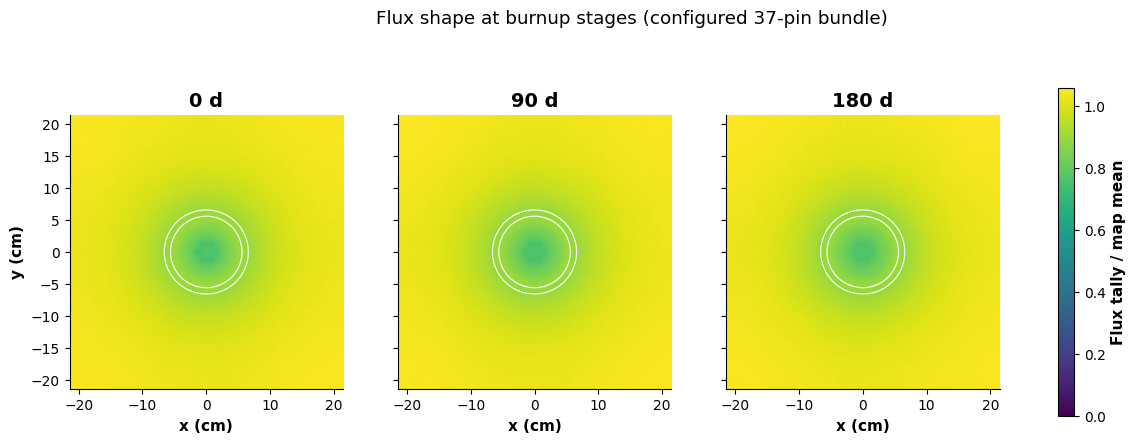

In [17]:
results = openmc.deplete.Results(depletion_folder / 'depletion_results.h5')
# OpenMC auto IDs differ across kernels; identify saved materials by name.
saved_material_ids = {results[0].get_material(mid).name: mid for mid in results[0].index_mat}
def result_material_id(material):
    return saved_material_ids[material.name]
cumulative_days = np.concatenate(([0.0], np.cumsum(DEPLETION_STEP_DAYS)))

available_neutron_data = {
    nuclide for entry in library.libraries if entry['type'] == 'neutron'
    for nuclide in entry['materials']
}

def prepare_stage_material(material, day):
    # Depletion records trace nuclides that the transport library may not contain.
    total = sum(n.percent for n in material.nuclides)
    missing = [n for n in material.nuclides if n.name not in available_neutron_data]
    omitted = sum(n.percent for n in missing)
    for nuclide in missing:
        material.remove_nuclide(nuclide.name)
    material.temperature = FUEL_TEMPERATURE_K
    if missing:
        print(f'{day:.0f} d, {material.name}: omitted {len(missing)} nuclides without '
              f'transport data ({omitted/total:.3%} of atom density)')
    return material

stage_flux_maps = []
for step in DEPLETION_FLUX_STAGE_STEPS:
    stage_uranium = results[step].get_material(result_material_id(depletion_uranium))
    stage_thorium = results[step].get_material(result_material_id(depletion_thorium))
    day = cumulative_days[step]
    stage_uranium = prepare_stage_material(stage_uranium, day)
    stage_thorium = prepare_stage_material(stage_thorium, day)
    stage_model = make_static_model(with_thorium=True, flux_tally=True, depletable_fuel=False,
                                     uranium_material=stage_uranium, thorium_material=stage_thorium)
    folder = WORK / f'flux_stage_{step}'
    folder.mkdir(parents=True, exist_ok=True)
    statepoint_path = folder / f'statepoint.{stage_model.settings.batches}.h5'
    if REUSE_CALCULATIONS and statepoint_path.is_file():
        print(f'Flux stage {step}: using saved {statepoint_path}')
    else:
        statepoint_path, _ = run_model_with_progress(stage_model, folder, f'flux stage {step}')
    with openmc.StatePoint(statepoint_path) as statepoint:
        keff = statepoint.keff
        tally = statepoint.get_tally(name='pin_pitch_flux_map')
        flux_map = tally.mean.reshape((FLUX_MESH_BINS, FLUX_MESH_BINS))
    day = cumulative_days[step]
    stage_flux_maps.append((day, flux_map / np.nanmean(flux_map)))
    print(f'Stage {step} ({day:.0f} d): k = {keff.nominal_value:.5f} ± {keff.std_dev:.5f}')

half_pitch = CHANNEL_PITCH_CM/2
fig, axes = plt.subplots(1, len(stage_flux_maps), figsize=(5*len(stage_flux_maps), 5), sharey=True)
if len(stage_flux_maps) == 1:
    axes = [axes]
vmax = max(np.nanmax(flux_map) for _, flux_map in stage_flux_maps)
for ax, (day, flux_map) in zip(axes, stage_flux_maps):
    im = ax.imshow(flux_map, origin='lower', cmap='viridis', vmin=0, vmax=vmax,
                   extent=(-half_pitch, half_pitch, -half_pitch, half_pitch))
    for radius in (PRESSURE_TUBE_OUTER_CM, CALANDRIA_TUBE_OUTER_CM):
        ax.add_patch(Circle((0, 0), radius, fill=False, edgecolor='white', lw=0.8))
    ax.set(xlabel='x (cm)', title=f'{day:.0f} d')
axes[0].set_ylabel('y (cm)')
fig.colorbar(im, ax=axes, label='Flux tally / map mean', shrink=0.85)
fig.suptitle('Flux shape at burnup stages (configured 37-pin bundle)')
plt.show()

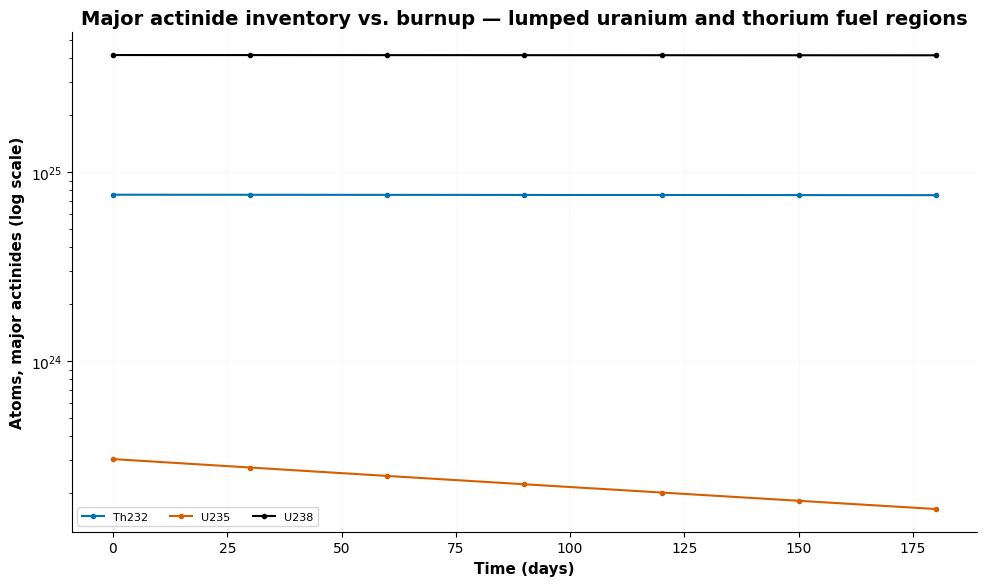

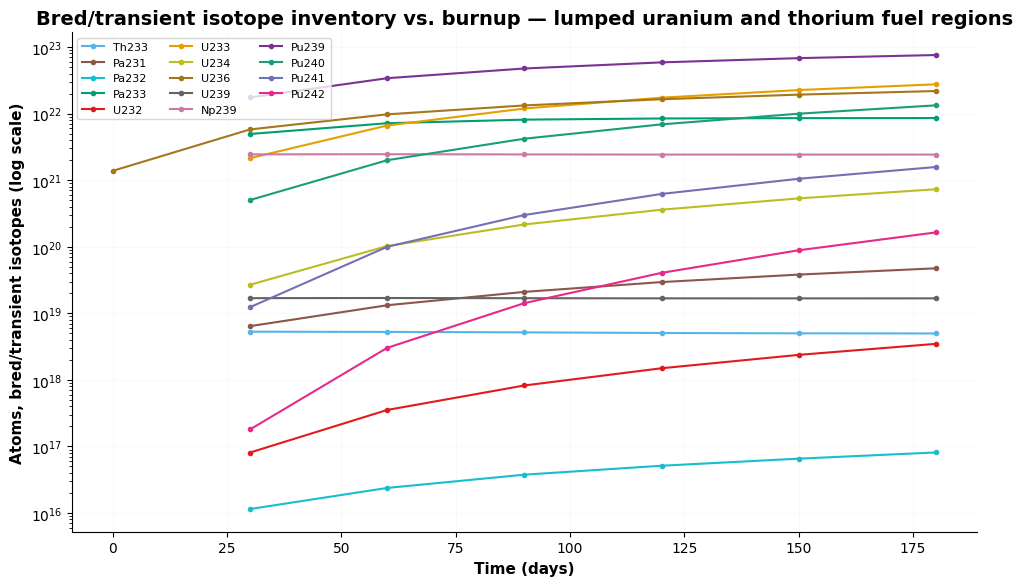

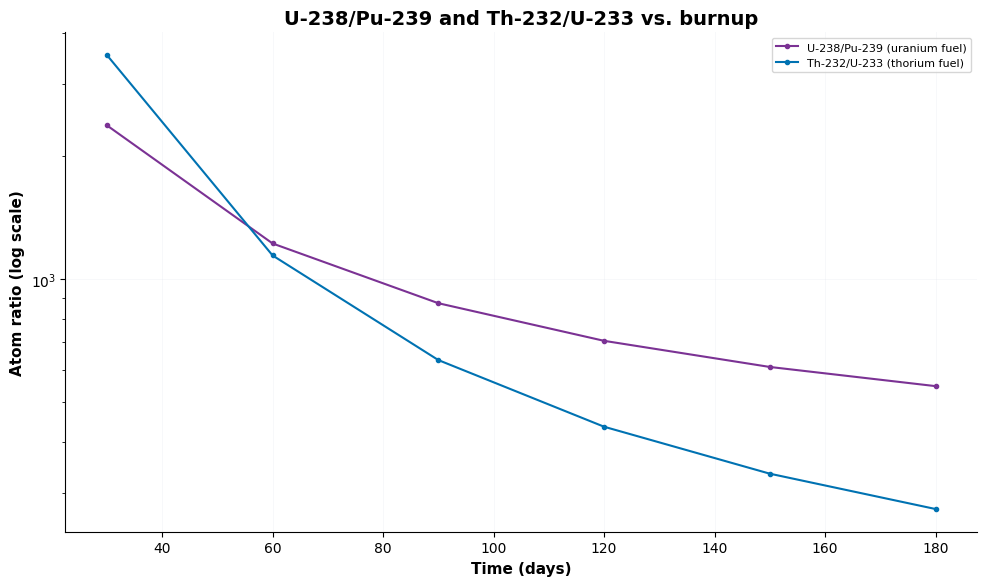

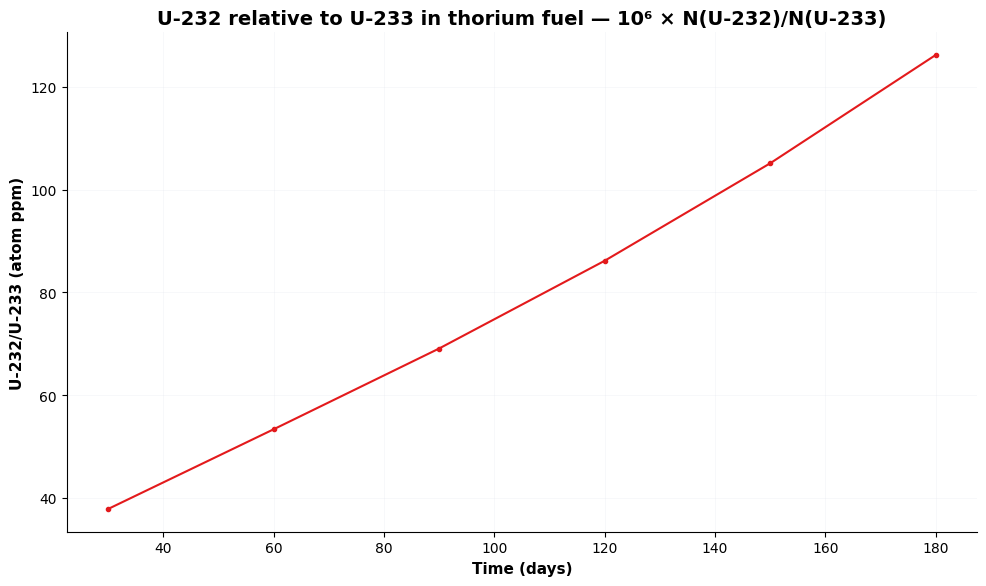

In [18]:
# Extended palette and line styles for the selected depletion nuclides.
ISO_COLORS = {
    'Th232': '#0072B2', 'Pa233': '#009E73', 'U233': '#E69F00',
    'U235': '#D55E00', 'U238': '#000000', 'Np239': '#CC79A7', 'Pu239': '#7B3294',
    'Th233': '#56B4E9', 'Pa231': '#8C564B', 'Pa232': '#17BECF',
    'U232': '#E31A1C', 'U234': '#BCBD22', 'U236': '#A6761D',
    'U239': '#636363', 'Pu240': '#1B9E77', 'Pu241': '#7570B3', 'Pu242': '#E7298A',
}
ISO_STYLES = {name: '-' for name in ISO_COLORS}

DEPLETION_MAJOR_ISOTOPES = ('Th232', 'U235', 'U238')
DEPLETION_BRED_ISOTOPES = tuple(
    nuclide for nuclide in DEPLETION_THORIUM_ISOTOPES + DEPLETION_URANIUM_ISOTOPES
    if nuclide not in DEPLETION_MAJOR_ISOTOPES
)

def isotope_series(material, nuclide):
    time_days, atoms = results.get_atoms(result_material_id(material), nuclide, time_units='d')
    return time_days, atoms

# Two separate figures replace the previous dual-axis inventory plot.
for group, title, ylabel in (
    (DEPLETION_MAJOR_ISOTOPES, 'Major actinide inventory vs. burnup',
     'Atoms, major actinides (log scale)'),
    (DEPLETION_BRED_ISOTOPES, 'Bred/transient isotope inventory vs. burnup',
     'Atoms, bred/transient isotopes (log scale)'),
):
    fig, ax = plt.subplots(figsize=(10, 6))
    for nuclide in group:
        material = depletion_thorium if nuclide in DEPLETION_THORIUM_ISOTOPES else depletion_uranium
        time_days, atoms = isotope_series(material, nuclide)
        ax.semilogy(time_days, np.where(atoms > 0, atoms, np.nan),
                    color=ISO_COLORS[nuclide], linestyle=ISO_STYLES[nuclide],
                    marker='o', markersize=3, label=nuclide)
    ax.set(xlabel='Time (days)', ylabel=ylabel,
           title=title + ' — lumped uranium and thorium fuel regions')
    ax.legend(fontsize=8, ncol=3)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

def isotope_ratio(material, numerator, denominator, scale=1.0):
    time_days, numerator_atoms = isotope_series(material, numerator)
    denominator_days, denominator_atoms = isotope_series(material, denominator)
    if not np.array_equal(time_days, denominator_days):
        raise ValueError('Isotope ratio time grids do not match')
    ratio = np.divide(numerator_atoms, denominator_atoms,
                      out=np.full_like(numerator_atoms, np.nan, dtype=float),
                      where=denominator_atoms > 0)
    return time_days, scale * ratio

fig, ax = plt.subplots(figsize=(10, 6))
for material, numerator, denominator, color, label in (
    (depletion_uranium, 'U238', 'Pu239', ISO_COLORS['Pu239'], 'U-238/Pu-239 (uranium fuel)'),
    (depletion_thorium, 'Th232', 'U233', ISO_COLORS['Th232'], 'Th-232/U-233 (thorium fuel)'),
):
    time_days, ratio = isotope_ratio(material, numerator, denominator)
    ax.semilogy(time_days, np.where(ratio > 0, ratio, np.nan),
                color=color, marker='o', markersize=3, label=label)
ax.set(xlabel='Time (days)', ylabel='Atom ratio (log scale)',
       title='U-238/Pu-239 and Th-232/U-233 vs. burnup')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

time_days, u232_ppm = isotope_ratio(depletion_thorium, 'U232', 'U233', scale=1e6)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time_days, u232_ppm, color=ISO_COLORS['U232'], marker='o', markersize=3)
ax.set(xlabel='Time (days)', ylabel='U-232/U-233 (atom ppm)',
       title='U-232 relative to U-233 in thorium fuel — 10⁶ × N(U-232)/N(U-233)')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## 5 · Pretty pictures

Saved /Users/user/Documents/OPENMC/ARTICLES/00_Th_Prolif/figures_v9/01_neutron_cross_sections.png


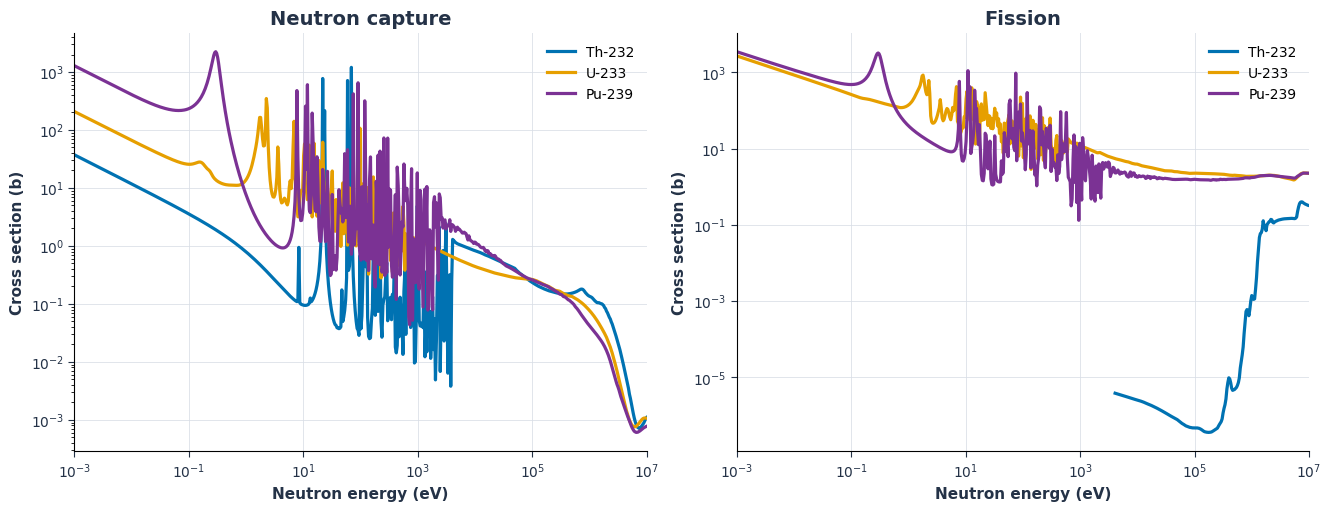

Saved /Users/user/Documents/OPENMC/ARTICLES/00_Th_Prolif/figures_v9/02_pin_loading_and_static_flux.png


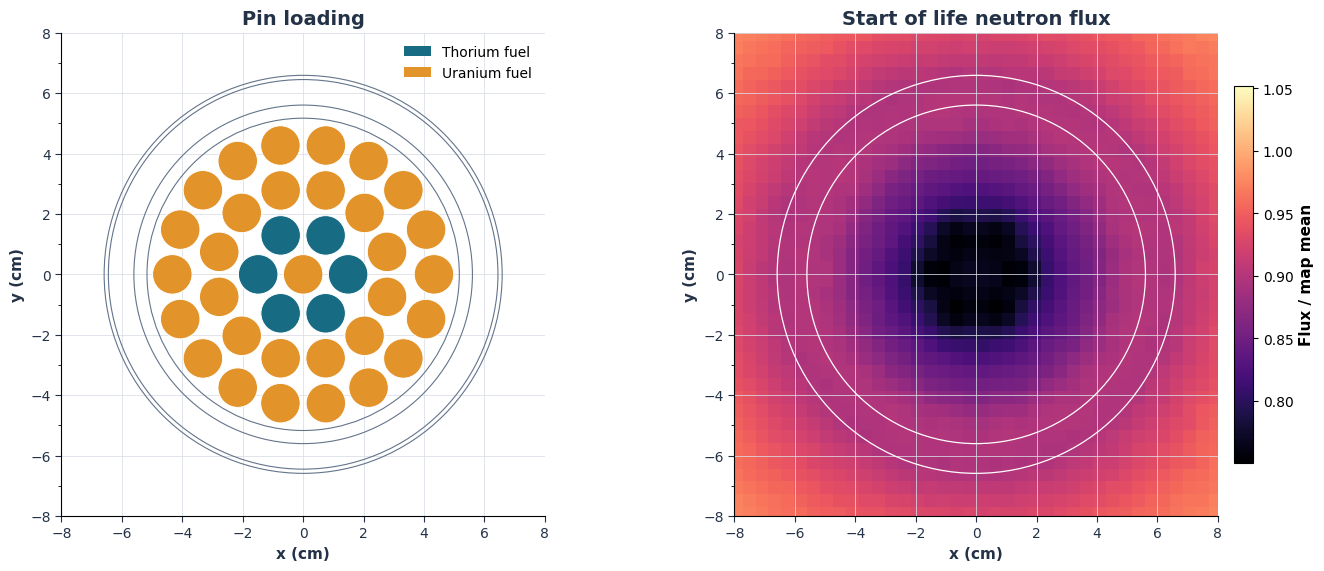

Saved /Users/user/Documents/OPENMC/ARTICLES/00_Th_Prolif/figures_v9/03_fuel_isotope_inventory.png


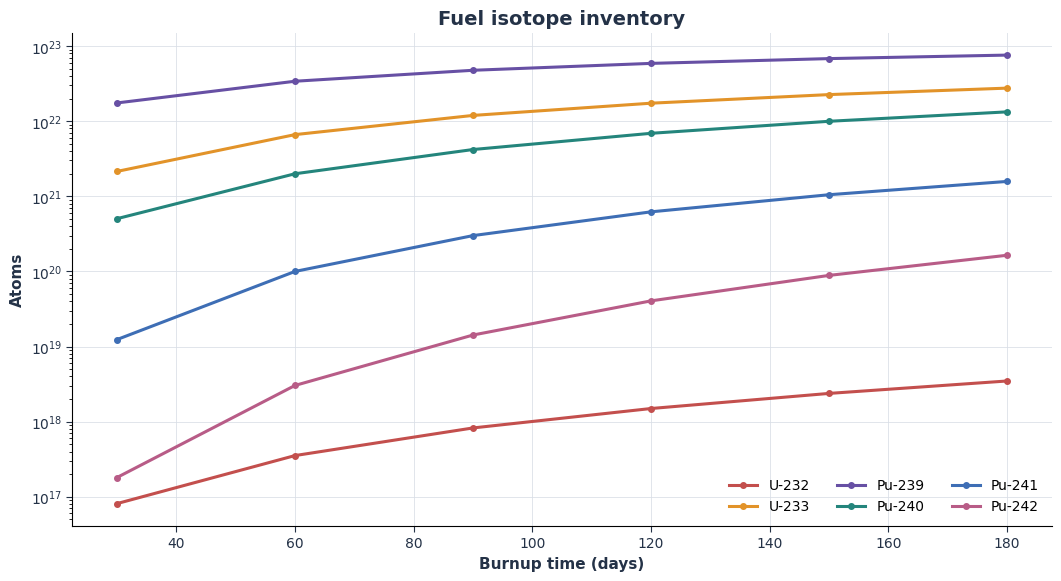

Saved /Users/user/Documents/OPENMC/ARTICLES/00_Th_Prolif/figures_v9/04_fuel_isotope_ratios.png


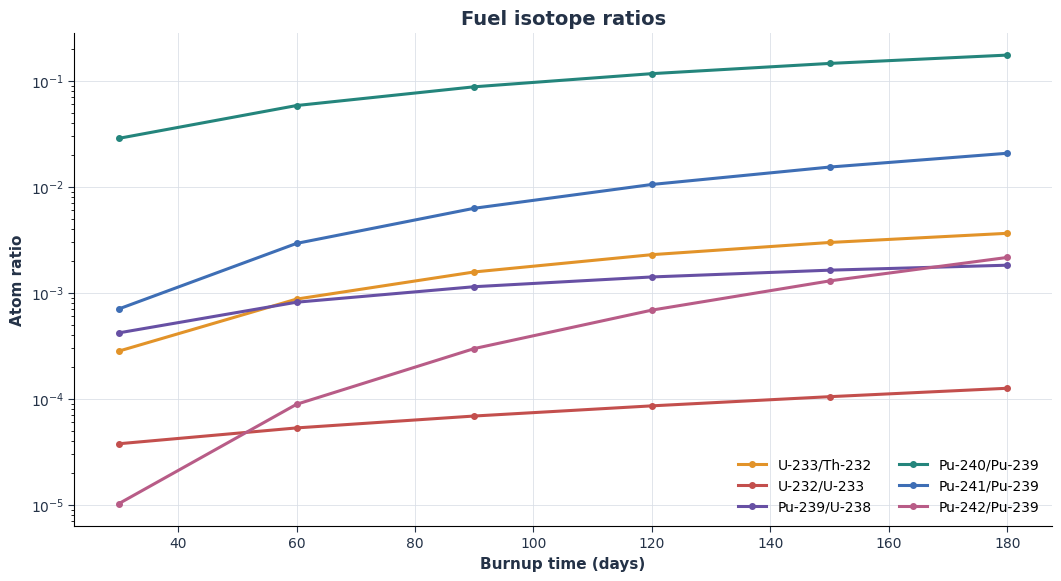

In [19]:
from matplotlib.ticker import AutoMinorLocator

INK = '#243247'
TH_COLOR = '#176B83'
U233_COLOR = '#E29329'
U232_COLOR = '#C34F4D'
PU_COLORS = {'Pu239': '#6750A4', 'Pu240': '#24857C',
             'Pu241': '#3E6EB5', 'Pu242': '#B85C87'}
FIG_DPI = 220

def polish(ax, *, log_y=False):
    ax.set_axisbelow(True)
    ax.grid(True, which='major', alpha=0.8)
    ax.tick_params(colors=INK, length=4)
    ax.title.set_color(INK)
    ax.xaxis.label.set_color(INK)
    ax.yaxis.label.set_color(INK)
    if not log_y:
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))

def save_figure(fig, name):
    path = FIGURES / name
    fig.savefig(path, dpi=FIG_DPI, bbox_inches='tight', pad_inches=0.16)
    print(f'Saved {path}')
    plt.show()

# Neutron capture and fission: two matched panels in one PNG.
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), constrained_layout=True)
for name in PLOT_ISOTOPES:
    label = name.replace('Th', 'Th-').replace('Pu', 'Pu-').replace('U', 'U-')
    for ax, mt in zip(axes, (102, 18)):
        y = xs(name, mt, energy_grid)
        ax.loglog(energy_grid, np.where(y > 0, y, np.nan),
                  color=COLORS[name], linewidth=2.3, label=label)
for ax, title in zip(axes, ('Neutron capture', 'Fission')):
    ax.set(title=title, xlabel='Neutron energy (eV)', ylabel='Cross section (b)',
           xlim=(energy_grid[0], energy_grid[-1]))
    polish(ax, log_y=True)
    ax.legend(frameon=False, loc='upper right')
save_figure(fig, '01_neutron_cross_sections.png')

# Pin loading and static flux share one visual scale and layout.
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6), constrained_layout=True)
ax = axes[0]
for ring, index, x, y in PIN_POSITIONS:
    fuel = PIN_LOADING[ring][index]
    ax.add_patch(Circle((x, y), CLAD_OUTER_RADIUS_CM,
                        facecolor=TH_COLOR if fuel == 'Th' else U233_COLOR,
                        edgecolor='white', lw=0.7))
for radius in (PRESSURE_TUBE_INNER_CM, PRESSURE_TUBE_OUTER_CM,
               CALANDRIA_TUBE_INNER_CM, CALANDRIA_TUBE_OUTER_CM):
    ax.add_patch(Circle((0, 0), radius, fill=False, edgecolor='#64748B', lw=0.8))
ax.legend(handles=[Patch(facecolor=TH_COLOR, label='Thorium fuel'),
                   Patch(facecolor=U233_COLOR, label='Uranium fuel')],
          loc='upper right', frameon=False)
ax.set(title='Pin loading', xlabel='x (cm)', ylabel='y (cm)',
       xlim=(-8, 8), ylim=(-8, 8), aspect='equal')
polish(ax)
ax = axes[1]
im = ax.imshow(normalized_flux, origin='lower', cmap='magma',
               extent=(-half_pitch, half_pitch, -half_pitch, half_pitch))
for radius in (PRESSURE_TUBE_OUTER_CM, CALANDRIA_TUBE_OUTER_CM):
    ax.add_patch(Circle((0, 0), radius, fill=False, edgecolor='white', lw=0.9))
ax.set(title='Start of life neutron flux', xlabel='x (cm)', ylabel='y (cm)',
       xlim=(-8, 8), ylim=(-8, 8), aspect='equal')
polish(ax)
fig.colorbar(im, ax=ax, label='Flux / map mean', shrink=0.78, pad=0.02)
save_figure(fig, '02_pin_loading_and_static_flux.png')

# A compact selection: the two bred uranium isotopes and the Pu-239 to Pu-242 chain.
selected = ('U232', 'U233', 'Pu239', 'Pu240', 'Pu241', 'Pu242')
styles = {name: '-' for name in selected}
colors = {'U232': U232_COLOR, 'U233': U233_COLOR, **PU_COLORS}
materials = {name: depletion_thorium if name.startswith('U') else depletion_uranium
             for name in selected}
fig, ax = plt.subplots(figsize=(10.5, 5.7), constrained_layout=True)
for name in selected:
    days, atoms = isotope_series(materials[name], name)
    ax.semilogy(days, np.where(atoms > 0, atoms, np.nan),
                label=name.replace('U', 'U-').replace('Pu', 'Pu-'),
                color=colors[name], ls=styles[name], lw=2.2,
                marker='o', ms=4)
ax.set(title='Fuel isotope inventory', xlabel='Burnup time (days)', ylabel='Atoms')
polish(ax, log_y=True)
ax.legend(frameon=False, ncol=3, loc='best')
save_figure(fig, '03_fuel_isotope_inventory.png')

# Ratios are calculated from the stored atom histories, with the mother isotope
# chosen separately for each plotted daughter.
ratio_specs = (
    ('U233', 'Th232', depletion_thorium),
    ('U232', 'U233', depletion_thorium),
    ('Pu239', 'U238', depletion_uranium),
    ('Pu240', 'Pu239', depletion_uranium),
    ('Pu241', 'Pu239', depletion_uranium),
    ('Pu242', 'Pu239', depletion_uranium),
)
fig, ax = plt.subplots(figsize=(10.5, 5.7), constrained_layout=True)
for numerator, denominator, material in ratio_specs:
    days, ratio = isotope_ratio(material, numerator, denominator)
    label = (numerator.replace('U', 'U-').replace('Pu', 'Pu-') + '/' +
             denominator.replace('Th', 'Th-').replace('U', 'U-').replace('Pu', 'Pu-'))
    ax.semilogy(days, np.where(ratio > 0, ratio, np.nan), label=label,
                color=colors[numerator], ls=styles[numerator], lw=2.2,
                marker='o', ms=4)
ax.set(title='Fuel isotope ratios', xlabel='Burnup time (days)', ylabel='Atom ratio')
polish(ax, log_y=True)
ax.legend(frameon=False, ncol=2, loc='best')
save_figure(fig, '04_fuel_isotope_ratios.png')
